# Importations

In [2]:
# Numerical and scientific python programming
import numpy as np

from scipy.stats import unitary_group, moment

import matplotlib.pyplot as plt

# Auxiliary python functions
from functools import reduce
from typing import Sequence

# Local importations
from moments.bloch import (compute_pauli_basis, compute_tensor_basis, compute_subset_index_map)

# Auxiliary functions 

In [15]:
def adj(A: np.ndarray) -> np.ndarray:
    return np.conj(A).T

def compute_hilbert_schmidt_inner_product(A: np.ndarray, B: np.ndarray) -> complex:
    if A.shape != B.shape:
        raise ValueError("A and B must have the same shape.")
    if len(A.shape) != 2 or A.shape[0] != A.shape[1]:
        raise ValueError("A and B must be square matrices of shape (d, d).")
    return np.trace(adj(A) @ B)

def compute_outer_product(psi: np.ndarray, phi: np.ndarray) -> np.ndarray:
    if psi.shape != phi.shape:
        raise ValueError("psi and phi must have the same shape.")
    if len(psi.shape) != 2 or psi.shape[1] != 1:
        raise ValueError("psi and phi must be column vectors of shape (d, 1).")
    return psi @ adj(phi)

def tensor_product(O_v: Sequence[np.ndarray]) -> np.ndarray:
    if not isinstance(O_v, (list, tuple)) or len(O_v) == 0:
        raise ValueError("O_v must be a non-empty list or tuple of numpy arrays.")
    for idx, o in enumerate(O_v):
        if not isinstance(o, np.ndarray):
            raise ValueError(f"Element at index {idx} is not a numpy array.")
        if o.size == 0:
            raise ValueError(f"Element at index {idx} is an empty array.")
    try:
        return reduce(np.kron, O_v)
    except ValueError as e:
        raise ValueError("Some arrays in O_v have incompatible shapes for Kronecker product.") from e

def compute_GHZ_state(N: int) -> np.ndarray:
    if N <= 0:
        return np.zeros((2**max(0, N), 1), dtype=complex)
    GHZ = np.zeros((2**N, 1), dtype=complex)
    GHZ[0, 0] = 1
    GHZ[2**N - 1, 0] = 1
    return GHZ / np.sqrt(2)

def compute_W_state(N: int) -> np.ndarray:
    if N <= 0:
        return np.zeros((2**max(0, N), 1), dtype=complex)
    W = np.zeros((2**N, 1), dtype=complex)
    for n in range(N):
        W[2**n, 0] = 1
    return W / np.sqrt(N)

def compute_partial_trace(N: int, n: int, rho: np.ndarray, canonical_basis: np.ndarray) -> np.ndarray:
    I_n = np.identity(2 ** n)
    I_N = np.identity(int(2 ** (N - n - 1)))
    tr_0 = np.kron(np.kron(I_n, canonical_basis[0]), I_N)
    tr_1 = np.kron(np.kron(I_n, canonical_basis[1]), I_N)
    return adj(tr_0) @ rho @ tr_0 + adj(tr_1) @ rho @ tr_1

# Random measurements

In [28]:
def compute_rand_U(d: int) -> np.ndarray:
    return unitary_group.rvs(d)

def compute_rand_LU(dim: Sequence[int]) -> np.ndarray:
    if not isinstance(dim, Sequence) or len(dim) == 0:
        raise ValueError("Input 'dim' must be a non-empty sequence of positive integers.")
    if not all(isinstance(d, int) and d > 0 for d in dim):
        raise ValueError("All dimensions in 'dim' must be positive integers.")
    return tensor_product([compute_rand_U(d) for d in dim])

def compute_obs_evol(O: np.ndarray, U: np.ndarray) -> np.ndarray:
    return U.conj().T @ O @ U

def compute_correlations_dist(dim: Sequence[int], rho: np.ndarray, O: np.ndarray, M: int) -> np.ndarray:
    correlations = np.zeros((1, M))
    for m in range(M):
        U = compute_rand_LU(dim)
        O_f = compute_obs_evol(O, U)
        correlations[0, m] = compute_hilbert_schmidt_inner_product(rho, O_f).real
    return correlations

# Definitions

In [17]:
dim = [2, 2]
N = len(dim)

pauli_basis = compute_pauli_basis()
local_bases = [pauli_basis.copy()] * N
local_basis_sizes = [len(basis) for basis in local_bases]

tensor_basis = compute_tensor_basis(local_bases)
subset_index_map = compute_subset_index_map(local_basis_sizes)

canonical_basis = [np.array([[1], [0]]), np.array([[0], [1]])]

# Correlation distributions

In [57]:
M = 2 ** 17

psi_p = np.kron(canonical_basis[0], canonical_basis[0])
psi_GHZ = compute_GHZ_state(N)
psi_W3 = compute_W_state(N + 1)

p = 1 / np.sqrt(3)

rho_p = compute_outer_product(psi_p, psi_p)
rho_GHZ = compute_outer_product(psi_GHZ, psi_GHZ)
rho_W3 = compute_outer_product(psi_W3, psi_W3)
rho_W2 = compute_partial_trace(N+1, 2, rho_W3, canonical_basis)
rho_w = (1 - p) / 4 * np.identity(4) + p * rho_GHZ

O = tensor_basis[15]

In [58]:
correlations_p = compute_correlations_dist(dim, rho_p, O, M)
correlations_GHZ = compute_correlations_dist(dim, rho_GHZ, O, M)
correlations_W3 = compute_correlations_dist(dim, rho_W2, O, M)
correlations_w = compute_correlations_dist(dim, rho_w, O, M)

# Results

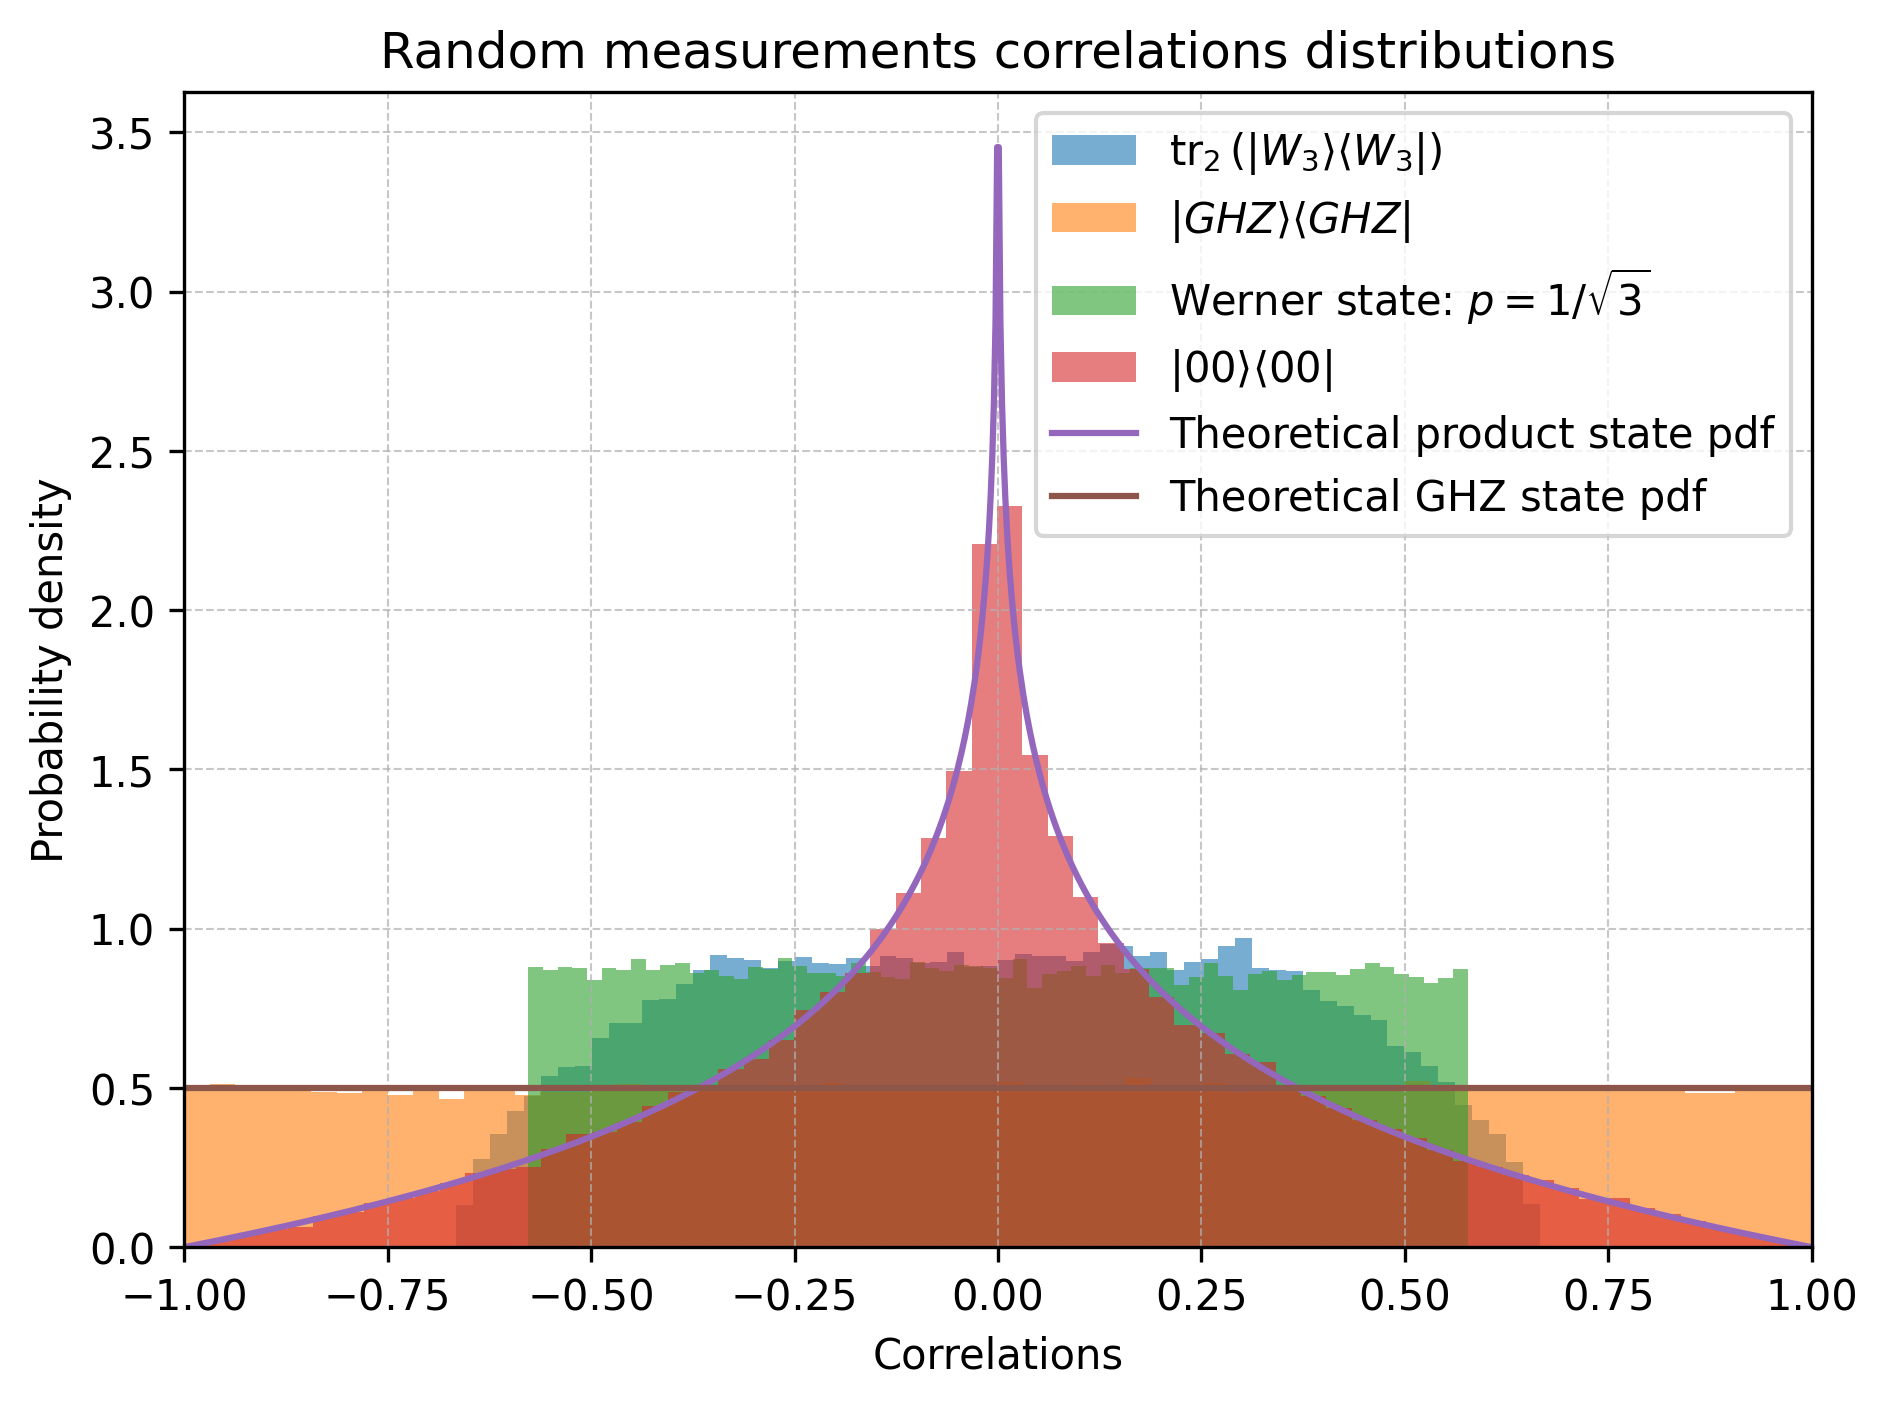

In [59]:
x = np.linspace(-1, 1, 1000)
correlations_p_th = - (1 / 2) * np.log(np.abs(x))
correlations_GHZ_th = (1 / 2) * np.ones((1, 1000))

fig, ax = plt.subplots(figsize = (7, 5), dpi=300)

ax.hist(correlations_W3[0], density = True, bins = 2 ** 6, alpha = 0.6, label = r"$\mathrm{tr}_2 \, ( | W_3 \rangle \langle W_3 | )$")
ax.hist(correlations_GHZ[0], density = True, bins = 2 ** 6, alpha = 0.6, label = r"$| GHZ \rangle \langle GHZ |$")
ax.hist(correlations_w[0], density = True, bins = 2 ** 6, alpha = 0.6, label = r"Werner state: $ p = 1 / \sqrt{3}$")
ax.hist(correlations_p[0], density = True, bins = 2 ** 6, alpha = 0.6, label = r"$| 00 \rangle \langle 00 |$")
ax.plot(x, correlations_p_th, label = "Theoretical product state pdf")
ax.plot(x, correlations_GHZ_th[0], label = "Theoretical GHZ state pdf")

ax.set_title("Random measurements correlations distributions")
ax.set_xlabel("Correlations")
ax.set_ylabel("Probability density")
ax.set_xlim(-1, 1)

ax.grid(True, which = "both", linestyle = "--", linewidth = 0.5, alpha = 0.7)
ax.legend()

plt.show()